In [ ]:
pip install mplsoccer

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Set pandas options to display all columns
pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_TempActual_Jugadores.xlsx')

In [ ]:
df_allplayers = df.copy()
df_allplayers.fillna(0, inplace=True)

In [ ]:
df_allplayers.drop('Equipo', axis=1, inplace=True)
df_allplayers.drop('Unnamed: 0', axis=1, inplace=True)
df_allplayers.rename(columns={'Equipo durante el período seleccionado': 'Equipo'}, inplace=True)

In [ ]:
#df_allplayers.head()

# **MÉTRICAS WYSCOUT**

In [ ]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                #'Duelos aéreos en los 90.1',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                #'Asistencias/90.1',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']
fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                #'Asistencias/90.1',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']
organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          #'Duelos aéreos en los 90.1',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles/90', 'Duelos atacantes ganados %', 'Remates/90', 'Regates/90',
             'Toques en el área de penalti/90', 'Tiros a la portería %', 'xG/90', 'Regates realizados %'
            ]

# **DICCIONARIO DE POSICIONES**

In [ ]:
# Diccionario de mapeo posiciones Wyscout -> categorías
mapa_posiciones = {
    "Portero": ["GK"],
    "Central": ["CB", "LCB", "RCB"],
    "Lateral": ["LB", "RB", "LWB", "RWB"],
    #"Carrilero": ["LWB", "RWB"],
    "Centrocampista": ["DMF", "LDMF", "RDMF", "LCMF", "RCMF", "AMF", "LAMF", "RAMF"],
    #"Media Punta": ["AMF", "LAMF", "RAMF"],
    "Extremo": ["LW", "RW", "RWF", "LWF"],
    "Delantero": ["CF"]
}

In [ ]:
# Definir métricas clave por posición ===
metricas_por_posicion = {
    "Portero": {
        "Goles recibidos/90": 0.25,
        "Paradas %": 0.25,
        "xG en contra/90": 0.20,
        "Goles evitados/90": 0.20,
        "Porterías imbatidas en los 90": 0.10
    },
    "Central": {
        "Duelos defensivos/90": 0.25,
        "Duelos defensivos ganados %": 0.25,
        "Interceptaciones/90": 0.20,
        "Pases progresivos/90": 0.15,
        "Duelos aéreos ganados %": 0.15
    },
    "Lateral": {
        "Entradas/90": 0.20, #lateral
        "Interceptaciones/90": 0.15, #lateral
        "Centros/90": 0.20, #comun
        "Precisión centros %": 0.15, #comun
        "Carreras en progresión/90": 0.15, #comun
        "Regates/90": 0.15 #comun
        #,"Acciones de ataque exitosas/90": 0.20 #carrilero
     },
    "centrocampista": {
        "Pases/90": 0.25,
        "Precisión pases %": 0.25,
        "Interceptaciones/90": 0.20,
        "Duelos defensivos ganados %": 0.15,
        "Recuperaciones/90": 0.15
        #,"Goles/90": 0.25, #media punta
        #,"Asistencias/90": 0.20, #media punta
        #,"xA/90": 0.20, #media punta
        #,"Regates/90": 0.15, #media punta
        #,"Key passes/90": 0.20 #media punta
    },
    #"medio organizador": {
    #    "Pases progresivos/90": 0.25,
    #    "Pases en el último tercio/90": 0.20,
    #    "Asistencias/90": 0.20,
    #    "xA/90": 0.20,
    #    "Key passes/90": 0.15
    #},
    "Extremo": {
        "Regates/90": 0.25,
        "Regates realizados %": 0.15,
        "Carreras en progresión/90": 0.20,
        "Centros/90": 0.15,
        "Precisión centros %": 0.10,
        "Goles/90": 0.15
    },
    "Delantero": {
        "Goles/90": 0.30,
        "xG/90": 0.25,
        "Tiros a portería %": 0.15,
        "Duelos ofensivos ganados %": 0.15,
        "Toques en el área de penalti/90": 0.15
    }
}


# **PARÁMETROS Y FILTROS**

In [ ]:
# =====================
# 2. Selección de posición
# =====================
pos_input = input("Introduce la posición (Portero, Lateral, Central, Centrocampista, Extremo, Delantero): ")


Introduce la posición (Portero, Lateral, Central, Centrocampista, Extremo, Delantero): Central


In [ ]:
#PARAMETROS
temp = "2025-2026"
min_jugados = 1
posicion = pos_input
compe = "1DIVI"

pos_rk = pos_input

plural = ""
if pos_rk == "Central" or pos_rk == "Lateral":
  plural = "es"
else:
  plural = "s"

if compe == "1DIVI":
  liga = "1ª División"
elif compe == "2DIVI":
  liga = "2ª División"
elif compe == "1RFEF":
  liga = "1ª RFEF"
elif compe == "2RFEF":
  liga = "2ª RFEF"



In [ ]:
#FILTRAMOS EL DATASET SEGÚN NECESIDAD
df_filtrado = df_allplayers[
                          (df_allplayers['Temporada'] == temp) &
                          (df_allplayers['Minutos jugados'] > min_jugados) &
                          (df_allplayers['Posición Principal'] == posicion) &
                          #(df_allplayers['Edad'] >= edad) # & (df_similares['Edad'] >= 'edad))
                          (df_allplayers['Competición'] == compe) # | (df_similares['Competición'] == compe2))
                          ]

In [ ]:
df_filtrado.head()

,Jugador,Equipo,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Posesión conquistada después de una entrada,Tiros interceptados/90,Interceptaciones/90,Posesión conquistada después de una interceptación,Faltas/90,Tarjetas amarillas,Tarjetas amarillas/90,Tarjetas rojas,Tarjetas rojas/90,Acciones de ataque exitosas/90,Goles/90,Goles (excepto los penaltis),"Goles, excepto los penaltis/90",xG/90,Goles de cabeza,Goles de cabeza/90,Remates,Remates/90,Tiros a la portería %,Goles hechos %,Asistencias/90,Centros/90,Precisión centros %,Centros desde la banda izquierda/90,Precisión centros desde la banda izquierda %,Centros desde la banda derecha/90,Precisión centros desde la banda derecha %,Centros al área pequeña/90,Regates/90,Regates realizados %,Duelos atacantes/90,Duelos atacantes ganados %,Toques en el área de penalti/90,Carreras en progresión/90,Aceleraciones/90,Pases recibidos /90,Pases largos recibidos/90,Faltas recibidas/90,Pases/90,Precisión pases %,Pases hacia adelante/90,Precisión pases hacia adelante %,Pases hacia atrás/90,Precision pases hacia atrás %,Pases laterales/90,Precisión pases laterales %,Pases cortos / medios /90,Precisión pases cortos / medios %,Pases largos/90,Precisión pases largos %,"Longitud media pases, m","Longitud media pases largos, m",xA/90,Asistencias/90.1,Second assists/90,Third assists/90,Desmarques/90,Precisión desmarques %,Jugadas claves/90,Pases en el último tercio/90,Precisión pases en el último tercio %,Pases al área de penalti/90,Pases hacía el área pequeña %,Pases en profundidad/90,Precisión pases en profundidad %,Ataque en profundidad/90,Centros desde el último tercio/90,Pases progresivos/90,Precisión pases progresivos %,Goles recibidos,Goles recibidos/90,Remates en contra,Remates en contra/90,Porterías imbatidas/90,Paradas %,xG en contra,xG en contra/90,Goles evitados,Goles evitados/90,Pases hacía atrás recibidos del arquero/90,Salidas/90,Duelos aéreos/90.1,Tiros libres/90,Tiros libres directos/90,Tiros libres directos %,Córneres/90,Penaltis a favor,Penaltis realizados %,Competición,Temporada,Pais_Comp,Flag,Posición Principal,Fecha_Actualizacion
10,R. Araújo,Barcelona,RCB,26,70000000,2031-06-30,2,187,0,0.06,0,0.00,10.59,54.55,Uruguay,Uruguay,derecho,188,79,no,5.78,3.85,62.50,5.29,54.55,0.48,1.30,0.48,2.89,7.83,2.41,0,0.00,0,0.0,0.48,0.0,0,0.0,0.03,0,0.0,1,0.48,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.48,100.0,0.48,100.00,0.48,0.96,0.00,35.13,0.48,0.00,48.13,90.00,14.44,73.33,2.41,100.0,26.95,96.43,45.24,94.68,2.89,16.67,19.31,41.20,0.00,0.00,0.0,0.0,0.0,0.0,0.00,6.74,64.29,0.00,0.0,0.0,0.0,0.00,0.00,5.29,81.82,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.93,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1DIVI,2025-2026,ESP,https://images.fotmob.com/image_resources/logo...,Central,2025-09-16 08:07:04.787
11,Éder Militão,Real Madrid,"RCB, LCB",27,60000000,2028-06-30,3,301,0,0.82,0,0.00,13.46,60.00,Brazil,Brazil,derecho,186,78,no,8.37,5.68,63.16,4.49,53.33,0.30,0.43,0.90,4.49,6.43,1.50,1,0.30,0,0.0,1.20,0.0,0,0.0,0.25,0,0.0,4,1.20,75.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.30,100.0,1.20,75.00,0.90,0.00,0.00,29.90,0.00,0.90,40.96,89.78,12.26,73.17,1.20,100.0,23.32,97.44,36.18,92.56,4.78,68.75,24.17,54.18,0.00,0.00,0.0,0.0,0.0,0.0,0.00,7.18,83.33,0.00,0.0,0.3,0.0,0.00,0.00,5.68,73.68,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.90,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1DIVI,2025-2026,ESP,https://images.fotmob.com/image_resources/logo...,Central,2025-09-16 08:07:04.787
23,A. Christensen,Barcelona,"LCB, CB",29,40000000,2026-06-30,2,122,0,0.12,0,0.00,10.33,57.14,Denmark,Denmark,derecho,187,82,no,5.16,2.21,33.33,5.16,71.43,0.00,0.00,0.00,4.43,8.18,0.74,0,0.00,0,0.0,0.00,0.0,0,0.0,0.09,0,0.0,1,0.74,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.

# **FUNCIÓN RENDIMIENTO**

In [ ]:
# === 3. Función para calcular índice de rendimiento por posición ===
def ranking_por_posicion(df_aux, posicion, top_n=10, plot=False):
    if posicion not in metricas_por_posicion:
        raise ValueError(f"Posición {posicion} no definida")

    metricas = metricas_por_posicion[posicion]
    posiciones_ws = mapa_posiciones[posicion]

    #df_pos = df_aux[df_aux["Posición Principal"] == posicion].copy()

    # Filtramos si "Posición específica" contiene alguna de las etiquetas
    mask = df_aux["Posición específica"].apply(lambda x: any(pos in str(x) for pos in posiciones_ws))
    df_pos = df_aux[mask].copy()

    if df_pos.empty:
        print(f"No hay jugadores para la posición: {posicion}")
        return pd.DataFrame()

    list_norm = []

    # Normalización Min-Max de cada métrica
    for metrica in metricas.keys():
        if metrica in df_pos.columns:
            df_pos[metrica + "_norm"] = (
                (df_pos[metrica] - df_pos[metrica].min()) /
                (df_pos[metrica].max() - df_pos[metrica].min() + 1e-6)
            )
        else:
            df_pos[metrica + "_norm"] = 0  # si no existe, la deja en 0
        list_norm.append(metrica + "_norm")

    # Índice ponderado
    df_pos["Rendimiento"] = sum(df_pos[m + "_norm"] * peso for m, peso in metricas.items())

    df_pos.drop_duplicates(inplace=True)
    ranking = df_pos.sort_values("Rendimiento", ascending=False).head(top_n)
    ranking["Jugador_Equipo"] = ranking["Jugador"] + " (" + ranking["Equipo"] + ")"

    # Gráfico
    if plot:

      #ESTILO
      bg = "#2d3137" #fondo
      tit = "#f4cf7f" #amarillo crema resto
      key = "#c1ff72" #verde lima num2-3
      impact = "#ef233c" #rojo num1
      white = "#ffffff"
      black = "#000000"

      plt.style.use("default")
      plt.figure(figsize=(10, 6), facecolor=bg)

      #plt.rcParams['figure.facecolor'] = black   # fondo exterior
      plt.rcParams['axes.facecolor'] = bg  # fondo interior de los ejes
      plt.rcParams['text.color'] = white
      plt.rcParams['axes.labelcolor'] = white
      plt.rcParams['xtick.color'] = white
      plt.rcParams['ytick.color'] = white

      bars = plt.barh(ranking["Jugador_Equipo"], ranking["Rendimiento"], color=tit)  # <- ahora sí definimos 'bars'
      plt.xlabel("Índice de rendimiento")
      #plt.ylabel("Jugador (Equipo)")

      plt.title(f"Top {top_n} - {posicion.capitalize()}"+plural, fontsize=14, fontweight="bold", pad=25, color=tit)

      # Subtítulo debajo del título (pero arriba del gráfico)
      plt.suptitle(
          liga + " " + temp,
          fontsize=10,
          color="gray",
          x=0.60,
          y=0.88  # controlas la posición vertical del subtítulo
        )

      #FIRMA
      plt.figtext(0.99, 0.01, "Hecho por @ManuelFLP", ha="right", fontsize=9, color="gray")
      #marca de agua
      plt.text(0.5, 0.5, "Hecho por @ManuelFLP",
         transform=plt.gca().transAxes, fontsize=30, color="gray",
         alpha=0.2, ha="center", va="center", rotation=30)

      # Texto en la esquina superior derecha (datos)
      plt.text(
        1.0,
        1.023,
        "Datos Wyscout",
        ha="right", va="bottom", transform=plt.gca().transAxes, fontsize=9, color="gray"
      )

      # Línea vertical con el promedio de los jugadores de su posición
      #promedio = df_pos["Rendimiento"].mean()
      #plt.axvline(promedio, color="red", linestyle="--", linewidth=1.5, label=f"Promedio {promedio:.2f}")
      #plt.legend()

      plt.xlim(0, 1.0)
      # Añadir etiquetas con el valor del rendimiento
      for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.01,            # posición X (un poco a la derecha de la barra)
            bar.get_y() + bar.get_height() / 2, # posición Y centrada
            f'{width:.3f}',           # valor con 3 decimales
            va="center",
            color = white, fontsize=9
          )

      plt.gca().invert_yaxis()
      #Resaltar los 3 primeros
      for i, b in enumerate(bars):
        if i == 0:
          b.set_color(impact)
        elif i < 3:
          b.set_color(key)

      plt.tight_layout()
      plt.show()

    #return ranking[["Jugador", "Equipo", "Posición Principal", "Posición específica", "Rendimiento"] + list(metricas.keys())]
    return ranking[["Jugador_Equipo", "Posición Principal", "Posición específica", "Rendimiento"] + list_norm]

# **LLAMADA A LA FUNCIÓN**

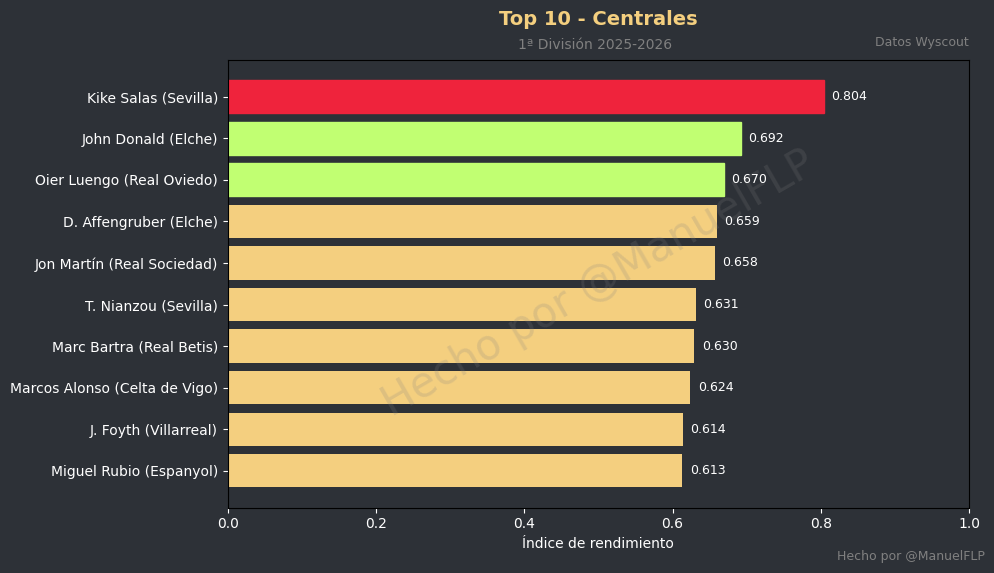

,Jugador_Equipo,Posición Principal,Posición específica,Rendimiento,Duelos defensivos/90_norm,Duelos defensivos ganados %_norm,Interceptaciones/90_norm,Pases progresivos/90_norm,Duelos aéreos ganados %_norm
375,Kike Salas (Sevilla),Central,LCB,0.803795,0.693694,0.6923,0.910209,0.930232,0.9048
304,John Donald (Elche),Central,"RCB, RB, LCMF",0.692463,1.000000,0.7778,0.757687,0.309868,0.3333
314,Oier Luengo (Real Oviedo),Central,"LCB, RCB",0.669557,0.666667,0.9167,0.531365,0.116279,1.0000
183,D. Affengruber (Elche),Central,"CB, RCB",0.659465,0.663964,0.8182,0.659287,0.491515,0.5556
404,Jon Martín (Real Sociedad),Central,RCB,0.657510,0.654955,0.6250,0.559656,0.685732,0.8182
214,T. Nianzou (Sevilla),Central,CB,0.631434,0.860360,0.5714,0.167282,0.600251,1.0000
315,Marc Bartra (Real Betis),Central,RCB,0.629572,0.508108,0.7600,0.804428,0.411062,0.6000
259,Marcos Alonso (Celta de Vigo),Central,LCB,0.624045,0.510811,0.4667,0.605166,0.974230,0.7500
78,J. Foyth (Villarreal),Central,RCB,0.613953,0.460360,0.8889,0.558426,0.499686,0.6000
299,Miguel Rubio (Espanyol),Central,"RCB, CB",0.613177,0.156757,1.0000,1.000000,0.255185,0.5714


In [ ]:
# === 4. Ranking ===
top_rk = ranking_por_posicion(df_filtrado, pos_rk, top_n=10, plot=True)
top_rk

In [ ]:
top_rk.columns

Index(['Jugador', 'Equipo', 'Posición Principal', 'Posición específica',
       'Rendimiento', 'Duelos defensivos/90_norm',
       'Duelos defensivos ganados %_norm', 'Interceptaciones/90_norm',
       'Pases progresivos/90_norm', 'Duelos aéreos ganados %_norm'],
      dtype='object')

In [ ]:
#Copiar y pegar las columnas norm obtenidas en la celda anterior
score_cols = ['Duelos defensivos/90_norm',
       'Duelos defensivos ganados %_norm', 'Interceptaciones/90_norm',
       'Pases progresivos/90_norm', 'Duelos aéreos ganados %_norm']

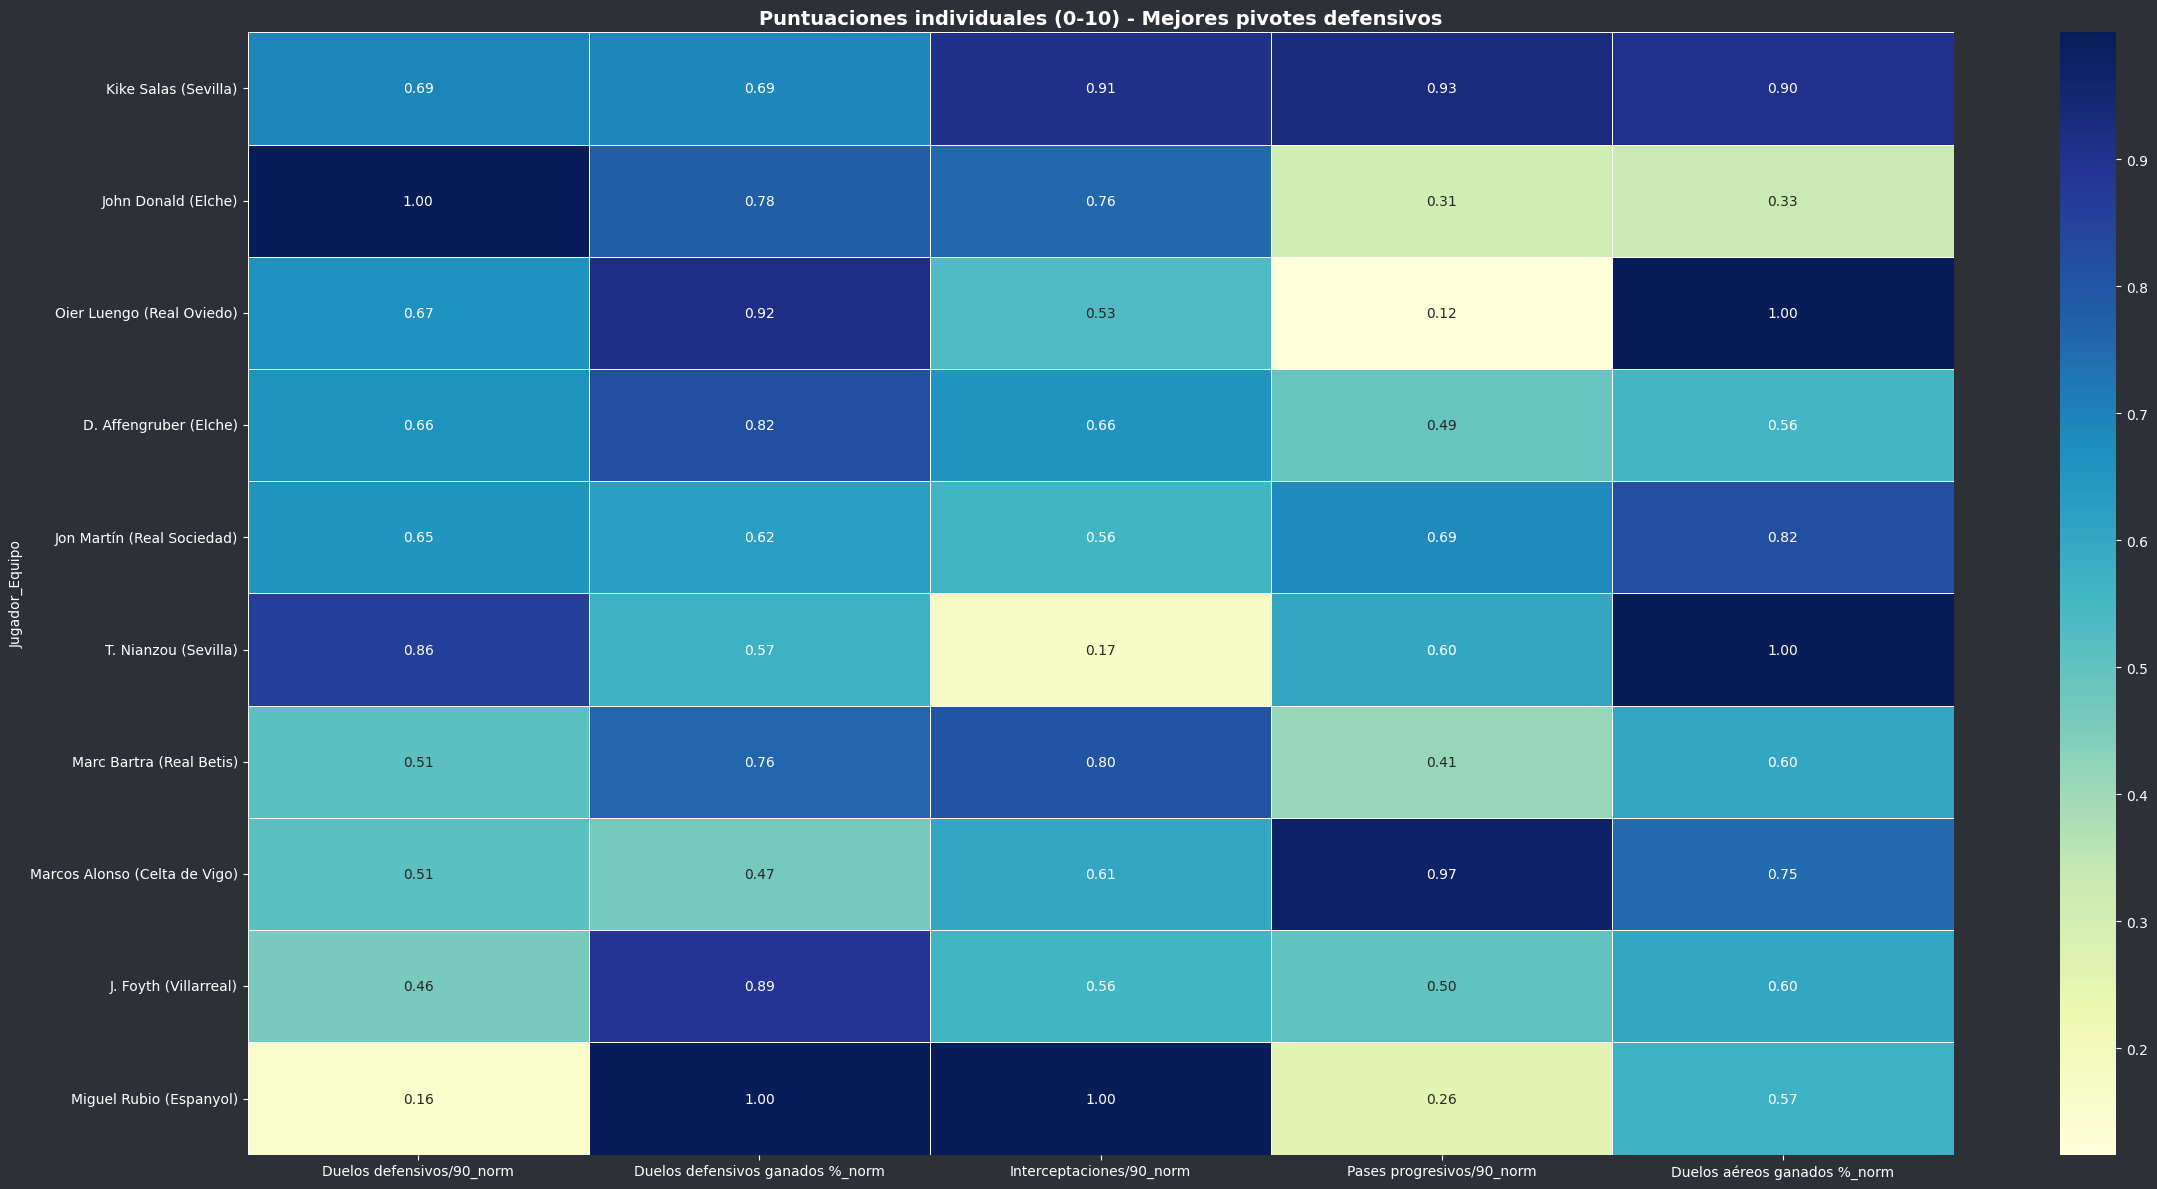

In [ ]:
# -------------------------------
# GRÁFICO FINAL: HEATMAP
# -------------------------------

# Seleccionamos el top 10 de jugadores de la celda anterior
top10 = top_rk.set_index("Jugador_Equipo")

# Dejamos únicamente las puntuaciones, sin datos innecesarios
scores_mtx = top10[score_cols]

plt.figure(figsize=(24, 12), facecolor="#2d3137")
sns.heatmap(scores_mtx, annot=True, cmap="YlGnBu", cbar=True, linewidths=0.5, fmt=".2f")
plt.title("Puntuaciones individuales (0-10) - Mejores pivotes defensivos", fontsize=14, weight="bold")
#plt.ylabel("Jugador")
#plt.xlabel("Métrica")
plt.tight_layout()
plt.show()